In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

### What is Regression Analysis?

**Regression Analysis** is the statistical process of modeling the relationship between a **dependent variable** (target $y$) and one or more **independent variables** (features $X$).


$$
y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_n X_n + \varepsilon
$$

| Symbol | Meaning |
|--------|---------|
| $y$ | Dependent variable (target) |
| $X_1, X_2, \dots, X_n$ | Independent variables (features) |
| $\beta_0$ | Intercept |
| $\beta_1, \beta_2, \dots, \beta_n$ | Coefficients (weights) |
| $\varepsilon$ | Error term (residuals) |



Residuals = Errors

$$
\text{Residual} = y_{\text{actual}} - y_{\text{predicted}}
$$



> **The Golden Rule:** Before you trust a regression model, you MUST check its residuals. The residuals (errors) should look like **"white noise"** — random and normally distributed.



What "White Noise" Means

| Characteristic | Description |
|----------------|-------------|
| **Random** | No pattern in residuals vs fitted values |
| **Normally Distributed** | Residuals follow a bell curve |
| **Zero Mean** | Average of residuals ≈ 0 |
| **Constant Variance** | Variance doesn't change with fitted values (homoscedasticity) |


### Linear Regression Assumptions

**Linear Regression** is a **"parametric"** model. It makes strict assumptions about the data. If you break these, your coefficients (weights) and p-values are completely meaningless.


| Assumption | What it means in plain English | How to check it |
|------------|--------------------------------|-----------------|
| **1. Linearity** | The relationship between $X$ and $y$ is a straight line | Scatter plot of $X$ vs $y$ |
| **2. Independence** | Samples are independent of each other | No time series leakage |
| **3. Homoscedasticity** | The errors have constant variance | Residuals vs Fitted plot |
| **4. Normality** | The errors are normally distributed | Q-Q Plot of residuals |



Why These Assumptions Matter

| Broken Assumption | Consequence |
|-------------------|-------------|
| **Non-linearity** | Model misses the true relationship |
| **Dependent samples** | Overly optimistic p-values |
| **Heteroscedasticity** | Unreliable confidence intervals |
| **Non-normal errors** | Invalid hypothesis tests |


> **If you break these assumptions, your coefficients and p-values are completely meaningless!** 🎯

In [4]:
np.random.seed(42)

# Create features
n_samples = 200
X = np.random.uniform(0, 10, n_samples).reshape(-1, 1)

# y = 2.5 * X + 5 + noise
noise = np.random.normal(0, 2, n_samples)  # Normally distributed noise
y = 2.5 * X.flatten() + 5 + noise

# outliers
outlier_indices = np.random.choice(n_samples, 10, replace=False)
y[outlier_indices] = y[outlier_indices] + np.random.normal(10, 5, 10)

data = pd.DataFrame({
    'X': X.flatten(),
    'y': y
})

# split
X_train, X_test, y_train, y_test = train_test_split(data[['X']], data['y'], test_size=0.2, random_state=42)

# model
model = LinearRegression()
model.fit(X_train, y_train)

# predict
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
y_pred_all = model.predict(data[['X']])

# residuals
residuals = data['y'] - y_pred_all

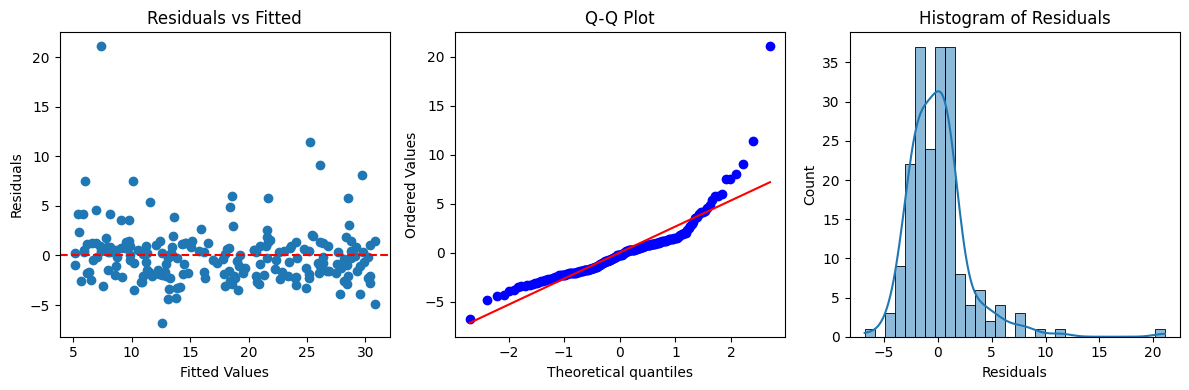

In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(y_pred_all, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')

plt.subplot(1, 3, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')

plt.subplot(1, 3, 3)
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.title('Histogram of Residuals')

plt.tight_layout()
plt.show()

### R² vs Adjusted R²



R² (Coefficient of Determination)

**R²** measures the proportion of variance in the target variable explained by the model.

$$
R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}
$$

| Component | Meaning |
|-----------|---------|
| $SS_{\text{res}}$ | Sum of squared residuals (unexplained variance) |
| $SS_{\text{tot}}$ | Total sum of squares (total variance) |

**Range:** 0 to 1 (0% to 100% variance explained)

**Problem:** R² **always increases** when you add more features — even if they're useless!

### Adjusted R²

**Adjusted R²** penalizes adding useless features. It only increases if the new feature actually improves the model.


R² vs Adjusted R²

| | R² | Adjusted R² |
|--|-----|-------------|
| **Adding useless features** | ✅ Increases | ❌ Decreases or stays same |
| **Adding useful features** | ✅ Increases | ✅ Increases |
| **Penalizes complexity?** | ❌ No | ✅ Yes |


> **Adjusted R² = R² with a penalty for extra features!**

$$
\text{Adjusted } R^2 = 1 - \left( \frac{(1 - R^2)(n - 1)}{n - p - 1} \right)
$$

Where:
- **$n$** = number of samples
- **$p$** = number of features

**Use Adjusted R² to compare models with different numbers of features!**

Adjusted R² matters MOST when:

- n is small (few samples)

- p is large (many features)

- You're adding useless features


In [21]:
np.random.seed(42)

X = np.random.rand(1000, 1)
y = np.random.rand(1000)

model1 = LinearRegression().fit(X, y)
print(model1.score(X, y)) 

X_bad = np.column_stack([X, np.random.rand(1000, 10)])
model2 = LinearRegression().fit(X_bad, y)
print(model2.score(X_bad, y))

0.0008590551111454792
0.013803694303434089


In [22]:
def adjusted_r2_score(y_true, y_pred, X):
    n = len(y_true)
    p = X.shape[1]
    r2 = r2_score(y_true, y_pred)
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print(adjusted_r2_score(y, model1.predict(X), X))
print(adjusted_r2_score(y, model2.predict(X_bad), X_bad))

-0.0001420881202061075
0.0028237759201727997


### Regression Metrics

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MSE** | $\frac{1}{n} \sum (y - \hat{y})^2$ | Average squared error |
| **RMSE** | $\sqrt{\text{MSE}}$ | Error in the same units as $y$ |
| **MAE** | $\frac{1}{n} \sum \|y - \hat{y}\|$ | Average absolute error |
| **R²** | $1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}$ | % of variance explained |
| **Adjusted R²** | $1 - \frac{(1 - R^2)(n - 1)}{n - p - 1}$ | R² penalized for features |
| **MAPE** | $\frac{1}{n} \sum \frac{\|y - \hat{y}\|}{y} \times 100$ | Percentage error (business) |